# Tutorial: Integrating adjacent DLPFC slices

This tutorial demonstrates MuSTHSC's ablility to integrate two adjacent slices (151674 and 151675). 

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from model import MuSTHSC

In [3]:
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import squidpy as sq
import scipy.sparse as sp
from scipy import sparse
from scipy.sparse import csr_matrix
import math
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.models as models
from torch_geometric.nn import GCNConv
import time
from itertools import chain
from scanpy import read_10x_h5
import sklearn
from sklearn.neighbors import kneighbors_graph
import gudhi
import networkx as nx
import random
import os
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
import json 
import matplotlib.image as mpimg

# load data

In [4]:
section_ids = ['151674','151675']
print(section_ids)

['151674', '151675']


In [5]:
def label_to_int(adataA, label_list, label_name):
    adata_label = np.array(adataA.obs[label_name].copy())
    for i in range(len(label_list)):
        need_index = np.where(adataA.obs[label_name]==label_list[i])[0]
        if len(need_index):
            adata_label[need_index] = i
    adataA.obs['ref'] = adata_label
    return adataA

In [6]:
adata_l = []
image_l = []
for i in range(len(section_ids)):
    adata_i = sc.read_h5ad('../dataset/DLPFC/DLPFC_'+ section_ids[i]+'_ST_final.h5ad')
    adata_i.obs_names = [x+'_'+section_ids[i] for x in adata_i.obs_names]
    adata_l.append(adata_i)

    img_path = f'../dataset/DLPFC/{section_ids[i]}/spatial/tissue_hires_image.png'
    if os.path.exists(img_path):
        img = Image.open(img_path)
        image_l.append(img)
    else:
        print(f"Warning: Image not found for section {section_ids[i]}")
        image_l.append(None)

In [7]:
from sklearn.preprocessing import StandardScaler
import torch
from torchvision import transforms
from PIL import ImageOps
import timm
import numpy as np
from sklearn.neighbors import kneighbors_graph
import sys
sys.path.insert(0, r'D:/Python/model/dino-main')
import torch
from utils import trunc_normal_
patch_size = 50
half = patch_size // 2
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = torch.hub.load('facebookresearch/dino:main', 'dino_vitb16')
#model = torch.hub.load('D:/Python/model/dino-main', 'dino_vitb16', source='local')
model.eval().to(device)
for param in model.parameters():
    param.requires_grad = True 
    
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

for adata, img in zip(adata_l, image_l):
    if img is None:
        continue

    spot_coords = adata.obsm['spatial']
    img_padded = ImageOps.expand(img, border=patch_size, fill='white')
    patches = []

    for coord in spot_coords:
        x, y = int(coord[0]), int(coord[1])
        left = x - half
        upper = y - half
        right = x + half
        lower = y + half
        patch = img_padded.crop((left, upper, right, lower))
        patch = ImageOps.pad(patch, (patch_size, patch_size), color='white')
        patch = transform(patch).unsqueeze(0).to(device)
        patches.append(patch)

    patches = torch.cat(patches, dim=0)

    features = []
    with torch.no_grad():
        for i in range(0, len(patches), 64):
            batch = patches[i:i+64]
            feat = model(batch)

            if feat.ndim == 3:
                feat = feat[:, 0, :] 
            elif feat.ndim == 2:
                pass  
            else:
                print(f"Skipping unexpected output shape: {feat.shape}")
                continue

            if feat.shape[1] != 768:  
                print(f"Skipping inconsistent feature size: {feat.shape}")
                continue

            features.append(feat.cpu().numpy())

    features = np.vstack(features)

    adata.obsm['image_features'] = features

    coords_scaled = StandardScaler().fit_transform(adata.obsm['spatial'])
    combined_feats = np.concatenate([features, coords_scaled], axis=1)
    A_img = kneighbors_graph(combined_feats, n_neighbors=5, mode='connectivity')
    adata.obsp['adj_i'] = A_img


Using cache found in /root/.cache/torch/hub/facebookresearch_dino_main


In [8]:
# convert label to int
label_list = ['Layer1', 'Layer2', 'Layer3', 'Layer4', 'Layer5', 'Layer6', 'WM']

In [9]:
for i in range(len(section_ids)):
    adata_l[i] = label_to_int(adata_l[i], label_list, 'Ground Truth')

In [10]:
adata0_sc = sc.read_h5ad('../dataset/DLPFC/DLPFC_sc_final.h5ad')

In [11]:
adata0_sc

AnnData object with n_obs × n_vars = 19764 × 3010
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cell_type', 'cell_subtype', 'subject', 'condition', 'batch', 'n_genes', 'ref'
    var: 'features', 'n_cells', 'n_counts'
    uns: 'rank_genes_groups'
    obsm: 'X_pca'
    obsp: 'adj_f'

In [12]:
label0_list = adata0_sc.obs['cell_subtype'].tolist()
adata0_label_new = adata0_sc.obs['cell_subtype'].tolist()
for i in range(len(label0_list)):
    need_index = np.where(adata0_sc.obs['cell_subtype'] == label0_list[i])[0]    
    if len(need_index):
        for p in range(len(need_index)):
            adata0_label_new[need_index[p]] = i  

In [13]:
adata0_sc.obs['ref'] = pd.Series(adata0_label_new, index = adata0_sc.obs['cell_subtype'].index)
adata0_sc.obs['ref'] = adata0_sc.obs['ref'].astype(str)
adata0_sc.obs['ref'] = adata0_sc.obs['ref'].astype('category')
adata0_sc.obs['Ground Truth'] = adata0_sc.obs['cell_subtype']

In [14]:
adata_l.append(adata0_sc)

In [15]:
len(adata_l)

3

# Run MuSTHSC

In [16]:
in_features = len(adata_l[0].var.index)
hidden_features = 512
out_features = 50

In [17]:
tag_l = ['ST','ST','single cell']

In [18]:
feature_method = 'GCNConv'
alpha = 0.001
beta = 1 
lamb = 0.01 
theta = 0.001
gamma = 10 
delta = 0.001
spatial_regularization_strength= 0.5
lr=1e-3
subepochs=100
epochs=200
max_patience=50
min_stop=20
random_seed=2025
gpu= 0
regularization_acceleration=True
edge_subset_sz=1000000

In [19]:
add_topology = True
add_feature = False
add_image = True
add_sc = True

In [20]:
multiscale = True

In [21]:
anchor_type = None
anchors_all = False
use_rep_anchor = 'embedding'
align_method = 'MMD'
anchor_size=8000

In [22]:
iter_comb= None
n_clusters_l = [7]
edge_weights = [1,0.1,0.1]
class_rep = 'reconstruct'

In [23]:
adata_l = MuSTHSC(adata_l, tag_l, section_ids, multiscale,  n_clusters_l, in_features, feature_method, hidden_features, out_features, iter_comb, anchors_all, use_rep_anchor, alpha, beta, lamb, theta, gamma, delta, edge_weights, add_topology, add_feature, add_image, add_sc, spatial_regularization_strength, lr=lr, subepochs=subepochs, epochs=epochs, class_rep = class_rep)

Pretraining to extract embeddings of spots...
epoch   0: train spatial C loss: 0.0000, train F loss: 65.1444,
epoch  10: train spatial C loss: 0.0000, train F loss: 39.1066,
epoch  20: train spatial C loss: 0.0000, train F loss: 39.0430,
epoch  30: train spatial C loss: 0.0000, train F loss: 38.9986,
epoch  40: train spatial C loss: 0.0000, train F loss: 38.9697,
epoch  50: train spatial C loss: 0.0000, train F loss: 38.9450,
epoch  60: train spatial C loss: 0.0000, train F loss: 38.9210,
epoch  70: train spatial C loss: 0.0000, train F loss: 38.8927,
epoch  80: train spatial C loss: 0.0000, train F loss: 38.8735,
epoch  90: train spatial C loss: 0.0000, train F loss: 38.8544,
Training classifier...
Training classifier...
epoch   0: overall loss: 3.5427,sc classifier loss: 3.5193,representation loss: 0.0023,within spatial regularization loss: 0.1341
epoch  10: overall loss: 1.7379,sc classifier loss: 1.7252,representation loss: 0.0013,within spatial regularization loss: 0.1154
epoch  2

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
Identifying anchors...
Processing datasets (0, 1)
0.8135713086238571
The ratio of filtered mnn pairs: 0.8087837967309867
Aligning by anchors...
epoch 100: total loss:38.8732, train F loss: 38.8598, train C loss: 1.9699, train D loss: 0.0134
epoch 110: total loss:38.8501, train F loss: 38.8410, train C loss: 0.8409, train D loss: 0.0091
epoch 120: total loss:38.8366, train F loss: 38.8300, train C loss: 0.6347, train D loss: 0.0066
epoch 130: total loss:38.8281, train F loss: 38.8225, train C loss: 0.5446, train D loss: 0.0056
epoch 140: total loss:38.8238, train F loss: 38.8187, train C loss: 0.4784, train D loss: 0.0051
epoch 150: total loss:38.8180, train F loss: 38.8133, train C loss: 0.4252, train D loss: 0.0047
epoch 160: total loss:38.8151, train F loss: 38.8105, train C loss: 0.3815, train D loss: 0.0047
epoch 170: total loss:38.8107, train F loss: 38.8062, train C loss: 0.3474, train D l

In [24]:
adata_concat_st = ad.concat(adata_l[0:len(section_ids)], label="slice_name", keys=section_ids)

In [25]:
sc.tl.pca(adata_concat_st)
adata_concat_st.obsm['X_pca_old'] = adata_concat_st.obsm['X_pca'].copy()
adata_concat_st.obsm['X_pca'] = adata_concat_st.obsm['embedding'].copy()
sc.pp.neighbors(adata_concat_st)  
sc.tl.umap(adata_concat_st)

In [26]:
sc.tl.leiden(adata_concat_st, random_state=666, key_added="leiden", resolution=0.18)
len(list(set(adata_concat_st.obs['leiden'].tolist())))

6

In [27]:
output_dir = 'Results/DLPFC'
os.makedirs(output_dir, exist_ok=True)

In [28]:
import analysis
analysis.mclust_R(adata_concat_st, num_cluster=7, used_obsm="embedding")

fitting ...
  |======================================================================| 100%


AnnData object with n_obs × n_vars = 7201 × 3010
    obs: 'in_tissue', 'array_row', 'array_col', 'Ground Truth', 'n_genes', 'image_cluster', 'dbscan_cluster_new', 'ref', 'pd_cluster', 'slice_name', 'leiden', 'mclust'
    uns: 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'features', 'features_summary_scale0.5_0.5', 'features_summary_scale0.5_1', 'features_summary_scale0.5_2', 'features_summary_scale1_0.5', 'features_summary_scale1_1', 'features_summary_scale1_2', 'features_summary_scale2_0.5', 'features_summary_scale2_1', 'features_summary_scale2_2', 'spatial', 'image_features', 'embedding', 'attention', 'hidden_spatial', 'hidden_image', 'reconstruct', 'deconvolution', 'X_pca_old', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

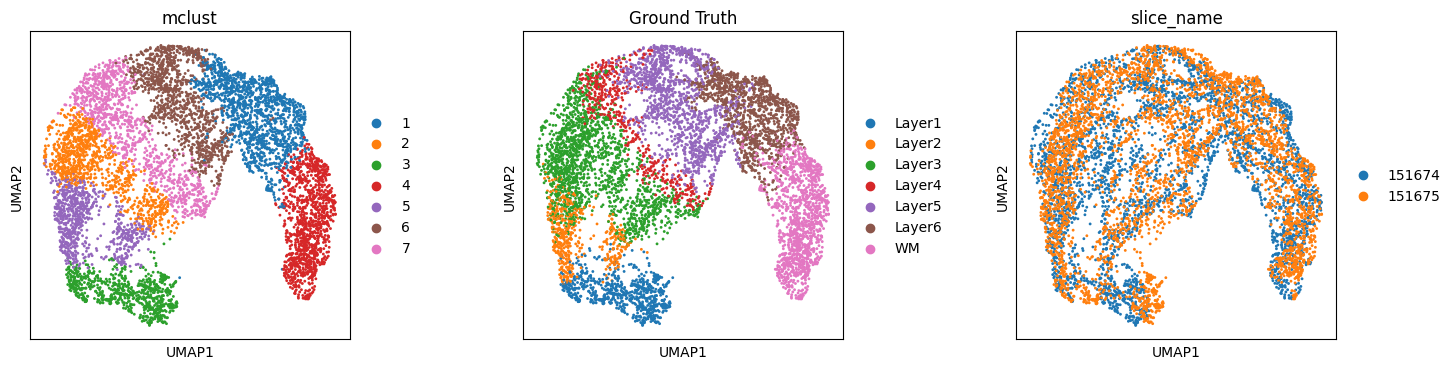

<Figure size 400x400 with 0 Axes>

In [29]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.umap(
    adata_concat_st,
    color=["mclust", 'Ground Truth', "slice_name"],
    wspace=0.4,
    save=False
)

plt.savefig(os.path.join(output_dir, f"DLPFC_umap_cluster_MuSTHSC_{'_'.join(section_ids)}.pdf"))
plt.show()

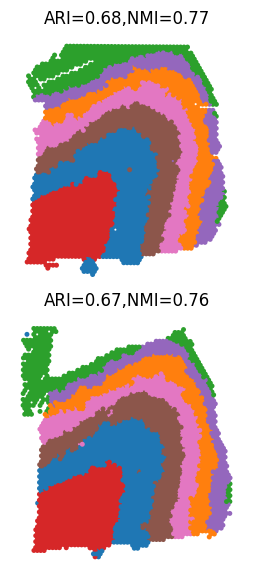

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
# split to each data
Batch_list = []
for section_id in section_ids:
    Batch_list.append(adata_concat_st[adata_concat_st.obs['slice_name'] == section_id])

spot_size = 200
title_size = 12
ARI_list = []
NMI_list = []
for bb in range(len(section_ids)):
    ARI_list.append(round(ari_score(Batch_list[bb].obs['Ground Truth'], Batch_list[bb].obs['mclust']), 2))
    NMI_list.append(round(nmi_score(Batch_list[bb].obs['Ground Truth'], Batch_list[bb].obs['mclust']), 2))

fig, ax = plt.subplots(2, 1, figsize=(3.5, 7), gridspec_kw={'wspace': 0.05, 'hspace': 0.1})
_sc_0 = sc.pl.spatial(Batch_list[0], img_key=None, color=['mclust'], title=[''],
                      legend_loc=None, legend_fontsize=12, show=False, ax=ax[0], frameon=False,
                      spot_size=spot_size)
_sc_0[0].set_title("ARI=" + str(ARI_list[0])+",NMI=" + str(NMI_list[0]), size=title_size)
_sc_1 = sc.pl.spatial(Batch_list[1], img_key=None, color=['mclust'], title=[''],
                      legend_loc=None, legend_fontsize=12, show=False, ax=ax[1], frameon=False,
                      spot_size=spot_size)
_sc_1[0].set_title("ARI=" + str(ARI_list[1])+",NMI=" + str(NMI_list[1]), size=title_size)
plt.savefig(os.path.join(output_dir, f"DLPFC_spatial_MuSTHSC_{'_'.join(section_ids)}.pdf"))
plt.show()

In [31]:
adata_l[0].uns['deconvolution']

,AAACAAGTATCTCCCA-1_151674_151674,AAACAATCTACTAGCA-1_151674_151674,AAACACCAATAACTGC-1_151674_151674,AAACAGAGCGACTCCT-1_151674_151674,AAACAGCTTTCAGAAG-1_151674_151674,AAACAGGGTCTATATT-1_151674_151674,AAACAGTGTTCCTGGG-1_151674_151674,AAACATTTCCCGGATT-1_151674_151674,AAACCCGAACGAAATC-1_151674_151674,AAACCGGGTAGGTACC-1_151674_151674,...,TTGTGTATGCCACCAA-1_151674_151674,TTGTGTTTCCCGAAAG-1_151674_151674,TTGTTAGCAAATTCGA-1_151674_151674,TTGTTCAGTGTGCTAC-1_151674_151674,TTGTTGTGTGTCAAGA-1_151674_151674,TTGTTTCACATCCAGG-1_151674_151674,TTGTTTCATTAGTCTA-1_151674_151674,TTGTTTCCATACAACT-1_151674_151674,TTGTTTGTATTACACG-1_151674_151674,TTGTTTGTGTAAATTC-1_151674_151674
Ex_8_L5_6,9.983769e-16,4.760155e-13,3.661348e-07,2.451589e-16,2.744113e-03,9.971741e-01,3.604908e-04,8.166456e-12,1.114981e-15,1.361880e-04,...,5.192060e-01,2.194121e-01,1.275909e-15,6.702576e-11,3.201508e-06,4.718508e-08,1.360465e-06,9.666973e-03,2.918511e-04,8.809843e-17
Micro/Macro,7.048992e-09,5.403412e-05,7.373461e-04,2.805877e-08,3.484293e-07,7.721599e-09,9.813483e-01,1.308452e-07,5.585975e-11,1.697353e-07,...,2.529257e-07,2.433587e-04,8.393487e-07,5.412170e-10,1.572863e-07,2.054775e-06,4.030933e-04,3.329746e-03,9.425811e-01,1.312334e-09
Mix_3,5.571938e-05,1.339405e-05,1.327350e-19,4.506682e-05,1.751510e-06,1.354990e-10,2.015531e-09,7.224887e-03,7.068278e-10,2.302692e-09,...,4.148399e-10,5.370698e-08,4.889576e-06,4.289330e-05,1.107601e-03,8.251861e-20,4.781285e-19,1.744956e-07,4.514042e-07,9.434820e-12
Oligos_1,2.108231e-17,2.612013e-18,4.509028e-03,8.911708e-18,1.444438e-11,1.709212e-11,4.425019e-06,5.054376e-13,4.987711e-20,6.423968e-13,...,6.208795e-13,1.060939e-09,1.394040e-15,5.237563e-15,7.545786e-12,3.659116e-05,3.144822e-06,1.918618e-09,4.385093e-07,1.483391e-23
Mix_4,1.633586e-06,5.246518e-02,3.203422e-11,5.549119e-06,1.882063e-06,4.984955e-07,9.084019e-06,2.199834e-05,1.448731e-07,1.081852e-04,...,9.173548e-07,4.499264e-06,2.218118e-05,2.806087e-04,3.837359e-03,7.361328e-12,1.688270e-09,2.397959e-04,5.816473e-05,8.536109e-07
Mix_5,2.778925e-03,6.826946e-03,1.494062e-16,1.568906e-04,1.283481e-02,1.088041e-06,3.722689e-07,6.070126e-01,1.313876e-05,4.027583e-06,...,1.936604e-05,5.978875e-05,8.038712e-07,7.213503e-04,6.108161e-03,7.296215e-16,1.459237e-14,2.685768e-04,4.348413e-07,4.296421e-08
Inhib_2_VIP,5.900267e-09,6.449029e-07,8.270210e-19,1.286166e-08,9.923058e-06,1.323738e-10,1.671488e-10,1.079748e-04,1.430529e-11,1.014536e-14,...,2.343022e-09,3.641399e-08,7.849630e-14,1.068697e-10,7.353601e-09,3.886849e-16,1.213669e-15,6.051306e-08,4.301459e-11,1.855440e-04
Ex_4_L_6,3.172737e-16,1.310160e-03,2.112240e-13,8.642373e-17,8.320647e-01,2.811925e-04,4.127065e-06,1.007091e-11,3.538416e-16,1.108092e-01,...,9.882097e-02,3.164880e-01,3.081451e-13,6.036482e-09,4.349614e-03,5.361369e-13,1.070379e-11,9.803650e-01,5.769679e-05,4.816332e-13
Inhib_4_SST,1.979359e-10,1.255363e-05,3.236931e-27,1.015678e-10,1.271373e-08,2.807067e-14,8.155777e-14,2.082997e-05,1.876813e-13,6.855775e-14,...,1.612404e-14,2.697921e-11,1.816301e-13,1.181702e-10,9.522553e-08,1.392995e-25,3.171045e-26,2.779373e-10,3.835944e-12,7.152619e-13
Ex_7_L4_6,2.525215e-17,8.888623e-11,4.106718e-20,4.467807e-19,5.875656e-03,1.923034e-05,2.483713e-13,1.740970e-11,8.987934e-19,1.815537e-06,...,3.528284e-06,1.964292e-06,1.389358e-14,3.653158e-05,1.841855e-02,6.244948e-17,2.708461e-19,7.417652e-08,5.461399e-14,8.013734e-20


In [32]:
# write out the deconvolution result
for i in range(len(adata_l)-1):
    adata_i = adata_l[i].copy()
    dev_i = adata_i.uns['deconvolution']
    dev_i.to_csv(os.path.join(output_dir, f'DLPFC_MuSTHSC_{section_ids[i]}.csv'), sep='\t')
    del adata_i.uns['deconvolution']
    del adata_i.uns['deconvolution_pre']

    adata_i.obs['ref'] = adata_i.obs['ref'].astype(str)

    for col in adata_i.obs.columns:
        if adata_i.obs[col].dtype.name not in ['category', 'object', 'string']:
            adata_i.obs[col] = adata_i.obs[col].astype(str)

    adata_i.write(os.path.join(output_dir, f'DLPFC_MuSTHSC_' + section_ids[i] + '_ST.h5ad'))
    del adata_i

adata_i = adata_l[len(section_ids)].copy()
adata_i.obs['ref'] = adata_i.obs['ref'].astype(str)
for col in adata_i.obs.columns:
    if adata_i.obs[col].dtype.name not in ['category', 'object', 'string']:
        adata_i.obs[col] = adata_i.obs[col].astype(str)
adata_i.write(os.path.join(output_dir, f"DLPFC_MuSTHSC_sc_{'_'.join(section_ids)}.h5ad"))